In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

from statsmodels.tsa.arima.model import ARIMA

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

C:\Users\HP\Desktop\New folder\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [48]:
df = pd.read_csv("C:\\Users\\HP\\Downloads\\kaggel_weather_2013_to_2024.csv")

df['DATE'] = pd.to_datetime(df['DATE'])

df = df.sort_values('DATE')

df.head()

,Unnamed: 0,DATE,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
0,0,2013-04-14,37.7,23.1,28.7,35.4,23.1,28.1,39.7,2.0,...,13,15,1496.69,917.07,1139.39,1405.38,917.07,1115.57,14.6,147.178118
1,1,2013-04-15,37.5,21.1,28.6,35.3,21.1,28.0,41.7,0.0,...,13,16,1563.75,879.87,1192.62,1472.01,879.87,1167.60,16.4,151.731061
2,2,2013-04-16,40.1,21.9,31.7,37.5,21.9,30.4,30.7,0.0,...,13,16,1231.07,672.33,973.19,1151.25,672.33,933.28,18.2,118.211133
3,3,2013-04-17,36.4,21.0,29.9,34.0,21.0,28.5,27.4,0.0,...,13,16,997.36,575.40,819.26,931.60,575.40,780.90,15.4,113.320354
4,4,2013-04-18,37.5,21.7,30.6,35.2,21.7,29.2,23.7,0.0,...,13,16,888.75,514.29,725.22,834.24,514.29,692.04,15.8,101.407038


In [49]:
table1 = pd.DataFrame({
    'Variable':[
        'temp',
        'humidity',
        'windspeed',
        'sealevelpressure',
        'precip'
    ],
    'Description':[
        'Average Temperature',
        'Humidity',
        'Wind Speed',
        'Sea Level Pressure',
        'Precipitation'
    ]
})

print(table1)

           Variable          Description
0              temp  Average Temperature
1          humidity             Humidity
2         windspeed           Wind Speed
3  sealevelpressure   Sea Level Pressure
4            precip        Precipitation


In [50]:
stats_table = df[
    ['temp','humidity','windspeed',
     'sealevelpressure','precip']
].describe()

print(stats_table)

              temp     humidity    windspeed  sealevelpressure       precip
count  3557.000000  3557.000000  3557.000000       3557.000000  3557.000000
mean     25.403374    63.755440    16.388249       1008.629238     2.459033
std       7.325541    18.129251     7.093090          7.005187    10.636255
min       6.500000    16.100000     5.400000        991.700000     0.000000
25%      19.100000    53.000000    12.300000       1002.500000     0.000000
50%      27.700000    65.800000    15.400000       1008.500000     0.000000
75%      31.000000    76.900000    18.400000       1014.900000     0.000000
max      39.500000    99.300000   203.800000       1024.200000   203.047000


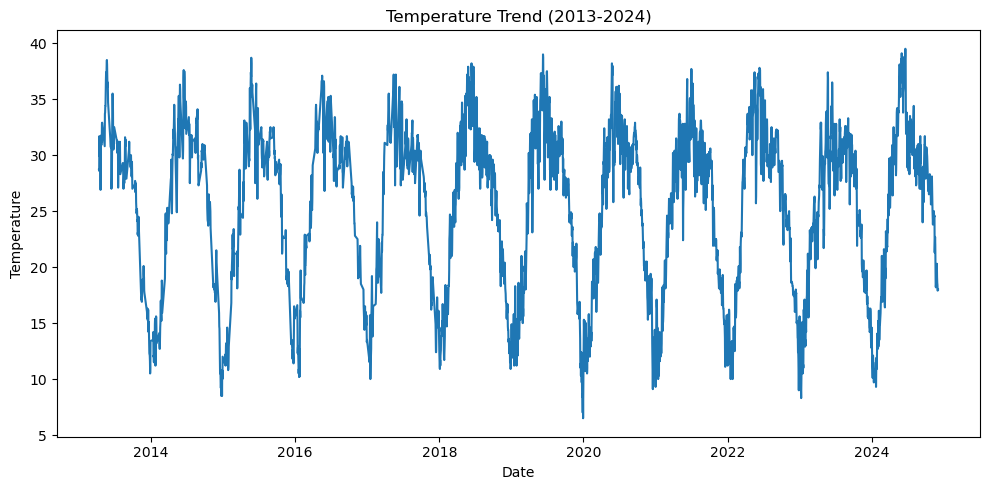

In [51]:
plt.figure(figsize=(10,5))

plt.plot(df['DATE'],df['temp'])

plt.title('Temperature Trend (2013-2024)')
plt.xlabel('Date')
plt.ylabel('Temperature')

plt.tight_layout()
plt.show()

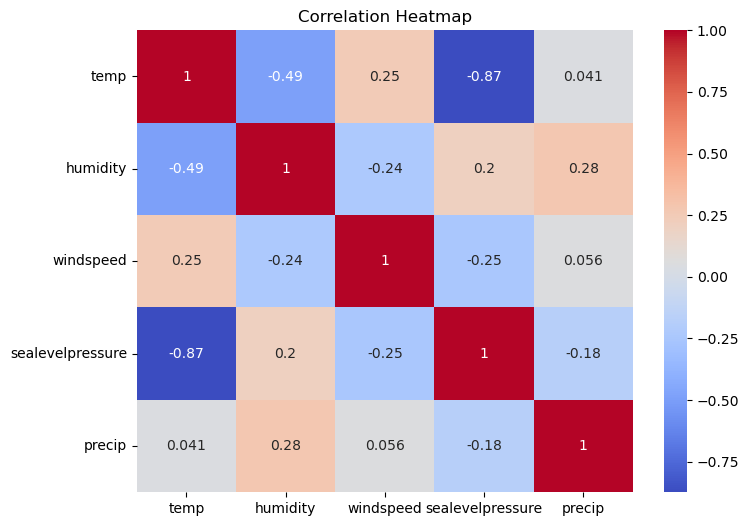

In [52]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['temp',
        'humidity',
        'windspeed',
        'sealevelpressure',
        'precip']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

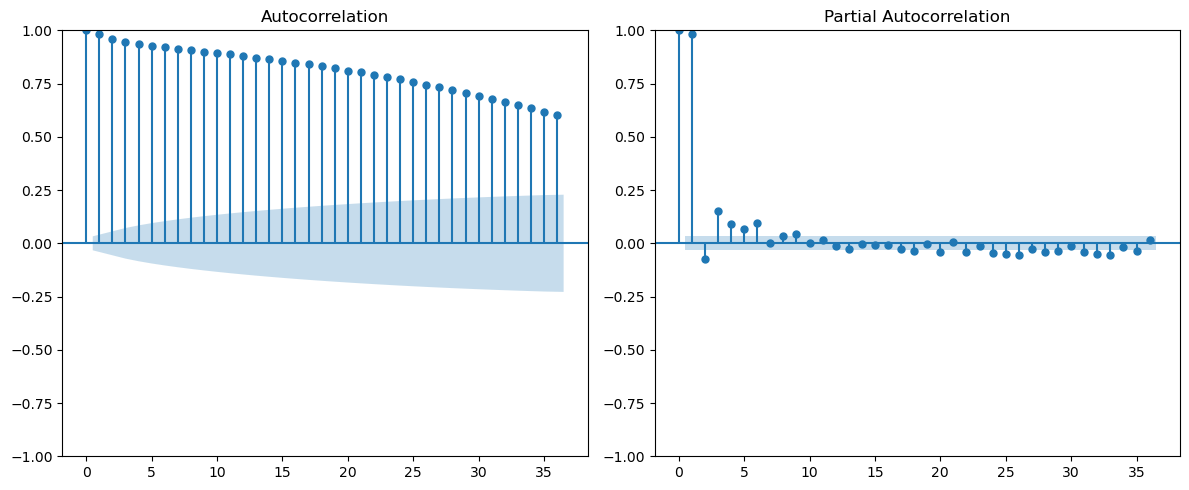

In [53]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(1,2,figsize=(12,5))

plot_acf(df['temp'], ax=ax[0])

plot_pacf(df['temp'], ax=ax[1])

plt.tight_layout()

plt.show()

In [54]:
train_size = int(len(df)*0.8)
train_size


2845

In [55]:
train = df.iloc[:train_size]
train

,Unnamed: 0,DATE,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
0,0,2013-04-14,37.7,23.1,28.7,35.4,23.1,28.1,39.7,2.0,...,13,15,1496.69,917.07,1139.39,1405.38,917.07,1115.57,14.6,147.178118
1,1,2013-04-15,37.5,21.1,28.6,35.3,21.1,28.0,41.7,0.0,...,13,16,1563.75,879.87,1192.62,1472.01,879.87,1167.60,16.4,151.731061
2,2,2013-04-16,40.1,21.9,31.7,37.5,21.9,30.4,30.7,0.0,...,13,16,1231.07,672.33,973.19,1151.25,672.33,933.28,18.2,118.211133
3,3,2013-04-17,36.4,21.0,29.9,34.0,21.0,28.5,27.4,0.0,...,13,16,997.36,575.40,819.26,931.60,575.40,780.90,15.4,113.320354
4,4,2013-04-18,37.5,21.7,30.6,35.2,21.7,29.2,23.7,0.0,...,13,16,888.75,514.29,725.22,834.24,514.29,692.04,15.8,101.407038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,2840,2022-12-15,22.6,8.9,15.0,22.6,8.7,15.0,56.4,0.0,...,22,50,1274.64,501.96,846.00,1274.64,490.68,846.00,13.7,249.247529
2841,2841,2022-12-16,22.6,10.0,15.1,22.6,10.0,15.1,58.5,0.0,...,22,50,1322.10,585.00,883.35,1322.10,585.00,883.35,12.6,253.158311
2842,2842,2022-12-17,23.0,8.9,15.2,23.0,8.9,15.2,61.7,0.0,...,22,50,1419.10,549.13,937.84,1419.10,549.13,937.84,14.1,258.676009
2843,2843,2022-12-18,23.0,8.9,15.1,23.0,8.9,15.1,71.7,0.0,...,22,50,1649.10,638.13,1082.67,1649.10,638.13,1082.67,14.1,273.091344


In [56]:
test = df.iloc[train_size:]
test

,Unnamed: 0,DATE,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
2845,2845,2022-12-20,22.1,8.0,13.7,22.1,6.8,13.6,79.0,0.0,...,22,51,1745.90,632.00,1082.30,1745.90,537.20,1074.40,14.1,289.171230
2846,2846,2022-12-21,19.7,9.0,13.6,19.7,9.0,13.6,81.3,0.0,...,22,51,1601.61,731.70,1105.68,1601.61,731.70,1105.68,10.7,290.749200
2847,2847,2022-12-22,19.1,8.0,12.4,19.1,6.8,12.2,84.2,0.0,...,22,51,1608.22,673.60,1044.08,1608.22,572.56,1027.24,11.1,301.460674
2848,2848,2022-12-23,19.1,8.0,12.6,19.1,7.4,12.5,80.5,0.0,...,22,51,1537.55,644.00,1014.30,1537.55,595.70,1006.25,11.1,298.982738
2849,2849,2022-12-24,18.6,7.0,11.8,18.6,5.6,11.5,80.9,0.0,...,22,51,1504.74,566.30,954.62,1504.74,453.04,930.35,11.6,306.008713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,3552,2024-11-26,25.8,13.6,18.6,25.8,13.6,18.6,65.9,0.0,...,24,48,1700.22,896.24,1225.74,1700.22,896.24,1225.74,12.2,242.171864
3553,3553,2024-11-27,26.2,12.5,18.4,26.2,12.5,18.4,61.0,0.0,...,24,48,1598.20,762.50,1122.40,1598.20,762.50,1122.40,13.7,236.769595
3554,3554,2024-11-28,25.8,11.5,17.9,25.8,11.5,17.9,63.1,0.0,...,24,48,1627.98,725.65,1129.49,1627.98,725.65,1129.49,14.3,243.117035
3555,3555,2024-11-29,25.0,10.6,18.0,25.0,10.6,18.0,60.0,0.0,...,24,48,1500.00,636.00,1080.00,1500.00,636.00,1080.00,14.4,237.638344


In [57]:
arima_model = ARIMA(
    train['temp'],
    order=(5,1,2)
)
arima_model


In [58]:
arima_fit = arima_model.fit()

arima_fit

In [59]:
arima_pred = arima_fit.forecast(
    steps=len(test)
)
arima_pred

2845    14.895737
2846    15.071189
2847    15.161451
2848    15.179429
2849    15.200756
          ...    
3552    15.158305
3553    15.158305
3554    15.158305
3555    15.158305
3556    15.158305
Name: predicted_mean, Length: 712, dtype: float64

In [60]:
features = [
    'humidity',
    'windspeed',
    'sealevelpressure',
    'precip',
    'month',
    'dayofyear',
    'weekofyear'
]
features


['humidity',
 'windspeed',
 'sealevelpressure',
 'precip',
 'month',
 'dayofyear',
 'weekofyear']

In [61]:
X_train = train[features]
X_train

,humidity,windspeed,sealevelpressure,precip,month,dayofyear,weekofyear
0,39.7,22.3,1008.3,2.0,4,104,15
1,41.7,17.6,1005.1,0.0,4,105,16
2,30.7,27.7,1001.7,0.0,4,106,16
3,27.4,22.3,1002.5,0.0,4,107,16
4,23.7,12.4,1003.4,0.0,4,108,16
...,...,...,...,...,...,...,...
2840,56.4,13.0,1014.9,0.0,12,349,50
2841,58.5,11.2,1014.0,0.0,12,350,50
2842,61.7,11.2,1015.7,0.0,12,351,50
2843,71.7,11.2,1016.0,0.0,12,352,50


In [62]:
X_test = test[features]
X_test


,humidity,windspeed,sealevelpressure,precip,month,dayofyear,weekofyear
2845,79.0,10.6,1014.0,0.0,12,354,51
2846,81.3,9.4,1015.3,0.0,12,355,51
2847,84.2,9.4,1015.2,0.0,12,356,51
2848,80.5,9.4,1014.3,0.0,12,357,51
2849,80.9,13.0,1015.9,0.0,12,358,51
...,...,...,...,...,...,...,...
3552,65.9,13.0,1015.5,0.0,11,331,48
3553,61.0,11.2,1015.0,0.0,11,332,48
3554,63.1,9.4,1016.8,0.0,11,333,48
3555,60.0,7.6,1017.4,0.0,11,334,48


In [63]:
y_train = train['temp']
y_train

0       28.7
1       28.6
2       31.7
3       29.9
4       30.6
        ... 
2840    15.0
2841    15.1
2842    15.2
2843    15.1
2844    14.7
Name: temp, Length: 2845, dtype: float64

In [64]:
y_test = test['temp']
y_test


2845    13.7
2846    13.6
2847    12.4
2848    12.6
2849    11.8
        ... 
3552    18.6
3553    18.4
3554    17.9
3555    18.0
3556    18.0
Name: temp, Length: 712, dtype: float64

In [65]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train,y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [66]:
xgb_pred = xgb.predict(X_test)
xgb_pred

array([15.319086 , 14.648007 , 14.179186 , 14.340472 , 13.3982115,
       14.53196  ,  8.124717 , 10.362069 , 12.737635 , 13.616118 ,
       12.870886 , 10.479441 , 12.550819 , 13.228651 , 11.950005 ,
       13.793315 , 13.299773 , 13.850421 , 14.210368 , 11.95201  ,
       11.839689 , 11.464751 , 11.683567 , 14.387476 , 11.381749 ,
       12.5738535, 14.686957 , 15.042994 , 14.865108 , 14.933277 ,
       15.81526  , 14.986858 , 13.946036 , 14.95587  , 14.563482 ,
       13.132247 , 12.535313 , 12.160138 , 14.362722 , 14.289493 ,
       15.0997505, 14.672174 , 12.787446 , 13.59089  , 14.744137 ,
       14.598962 , 15.633253 , 16.976545 , 18.010876 , 17.917902 ,
       16.249905 , 17.639797 , 18.987797 , 17.703695 , 15.974415 ,
       17.218878 , 17.885466 , 18.161636 , 19.077133 , 19.104126 ,
       19.982885 , 20.47299  , 21.101292 , 20.031515 , 20.49021  ,
       20.615076 , 20.62075  , 20.485117 , 20.76802  , 20.427053 ,
       19.743916 , 19.579948 , 20.289623 , 20.194847 , 20.4504

In [67]:
train_pred_arima = arima_fit.predict(
    start=1,
    end=len(train)-1
)
train_pred_arima

1       28.700004
2       28.593505
3       31.951228
4       29.311857
5       30.640283
          ...    
2840    16.519233
2841    15.079690
2842    15.545288
2843    15.435053
2844    15.295043
Name: predicted_mean, Length: 2844, dtype: float64

In [68]:

residuals = train['temp'][1:] - train_pred_arima
residuals

1      -0.100004
2       3.106495
3      -2.051228
4       1.288143
5      -0.340283
          ...   
2840   -1.519233
2841    0.020310
2842   -0.345288
2843   -0.335053
2844   -0.595043
Length: 2844, dtype: float64

In [69]:
X_train_res = X_train.iloc[1:]
X_train_res


,humidity,windspeed,sealevelpressure,precip,month,dayofyear,weekofyear
1,41.7,17.6,1005.1,0.0,4,105,16
2,30.7,27.7,1001.7,0.0,4,106,16
3,27.4,22.3,1002.5,0.0,4,107,16
4,23.7,12.4,1003.4,0.0,4,108,16
5,27.2,14.8,1004.0,0.0,4,109,16
...,...,...,...,...,...,...,...
2840,56.4,13.0,1014.9,0.0,12,349,50
2841,58.5,11.2,1014.0,0.0,12,350,50
2842,61.7,11.2,1015.7,0.0,12,351,50
2843,71.7,11.2,1016.0,0.0,12,352,50


In [70]:
xgb_residual = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
xgb_residual


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [71]:
xgb_residual.fit(
    X_train_res,
    residuals
)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [72]:
residual_forecast = xgb_residual.predict(X_test)
residual_forecast

array([ 2.40635023e-01, -2.34016385e-02, -7.77366534e-02,  2.47861743e-02,
       -7.32034370e-02, -1.61630476e+00, -1.51582730e+00, -8.52478385e-01,
       -3.22805911e-01, -1.05355782e-02, -5.93995988e-01,  1.78531054e-02,
        3.13297987e-01,  2.58609325e-01,  4.62527037e-01,  1.25098601e-01,
       -5.20042121e-01, -6.06681406e-01,  1.25098601e-01,  3.16205978e-01,
       -3.79068077e-01, -5.72834730e-01, -1.02118468e+00, -1.99556768e+00,
       -5.11371613e-01, -5.34721255e-01, -2.78947800e-02,  9.46683168e-01,
        4.38362151e-01,  8.75927329e-01,  1.64202690e+00,  1.33017802e+00,
        1.04283154e+00,  1.31346595e+00,  1.43300092e+00,  1.23591393e-01,
       -7.73339391e-01, -6.74907327e-01,  5.72740257e-01,  1.05725884e+00,
       -9.26552653e-01, -1.99968433e+00, -1.05801976e+00, -1.53677449e-01,
        5.30561030e-01,  6.40785098e-01,  5.17448306e-01,  9.31852400e-01,
        1.27342391e+00,  5.42449534e-01,  5.08778214e-01,  1.08112741e+00,
        1.08804619e+00,  

In [73]:
hybrid_pred = arima_pred + residual_forecast
hybrid_pred

2845    15.136372
2846    15.047788
2847    15.083715
2848    15.204215
2849    15.127553
          ...    
3552    14.823444
3553    15.029686
3554    15.204888
3555    14.929405
3556    15.222974
Name: predicted_mean, Length: 712, dtype: float64

In [74]:
results = pd.DataFrame({

'Model':['ARIMA',
          'XGBoost',
          'Hybrid ARIMA-XGBoost'],

'MAE':[

mean_absolute_error(y_test,arima_pred),

mean_absolute_error(y_test,xgb_pred),

mean_absolute_error(y_test,hybrid_pred)
],

'RMSE':[

np.sqrt(mean_squared_error(y_test,arima_pred)),

np.sqrt(mean_squared_error(y_test,xgb_pred)),

np.sqrt(mean_squared_error(y_test,hybrid_pred))
],

'MAPE':[

mean_absolute_percentage_error(
    y_test,
    arima_pred
)*100,

mean_absolute_percentage_error(
    y_test,
    xgb_pred
)*100,

mean_absolute_percentage_error(
    y_test,
    hybrid_pred
)*100

]

})

print(results)

                  Model        MAE       RMSE       MAPE
0                 ARIMA  10.927809  12.500912  39.591987
1               XGBoost   1.355959   1.718112   6.401247
2  Hybrid ARIMA-XGBoost  10.923540  12.476588  39.623497


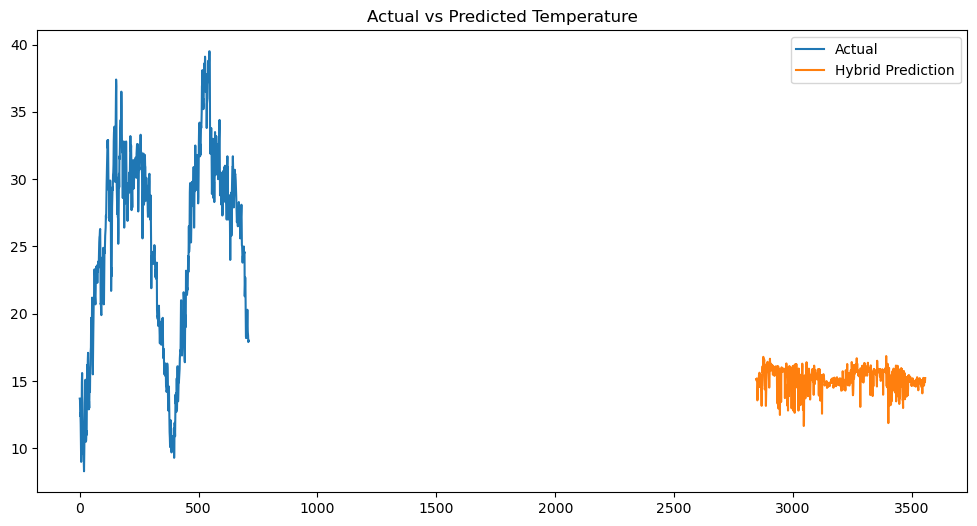

In [75]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    hybrid_pred,
    label='Hybrid Prediction'
)

plt.legend()

plt.title(
    'Actual vs Predicted Temperature'
)

plt.show()

In [76]:
explainer = shap.TreeExplainer(
    xgb_residual
)

shap_values = explainer.shap_values(
    X_test
)

NameError: name 'shap' is not defined

In [77]:
shap.summary_plot(
    shap_values,
    X_test
)

NameError: name 'shap' is not defined

In [88]:
!pip install shap

In [92]:
import shap

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\HP\Desktop\New folder\Lib\site-packages\IPython\core\interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\HP\AppData\Local\Temp\ipykernel_4824\3975714860.py", line 1, in <module>
    import shap
  File "C:\Users\HP\Desktop\New folder\Lib\site-packages\shap\__init__.py", line 88, in <module>
    from . import datasets, links, utils  # noqa: E402
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\HP\Desktop\New folder\Lib\site-packages\shap\datasets.py", line 6, in <module>
    import sklearn.datasets
  File "C:\Users\HP\Desktop\New folder\Lib\site-packages\sklearn\datasets\__init__.py", line 25, in <module>
    from ._olivetti_faces import fetch_olivetti_faces
  File "C:\Users\HP\Desktop\New folder\Lib\site-packages\sklearn\datasets\_olivetti_faces.py", line 21, in <module>
    from scipy.io import loadmat
  File "C:\Users\HP\Desktop\New folder\Lib\site-packages\scip

In [99]:
ImportError: cannot import name '_sub_module_deprecation'
from scipy._lib.deprecation

SyntaxError: invalid syntax (1044708396.py, line 1)

In [94]:
import scipy
import sklearn

print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

SciPy: 1.11.1
Scikit-learn: 1.3.0


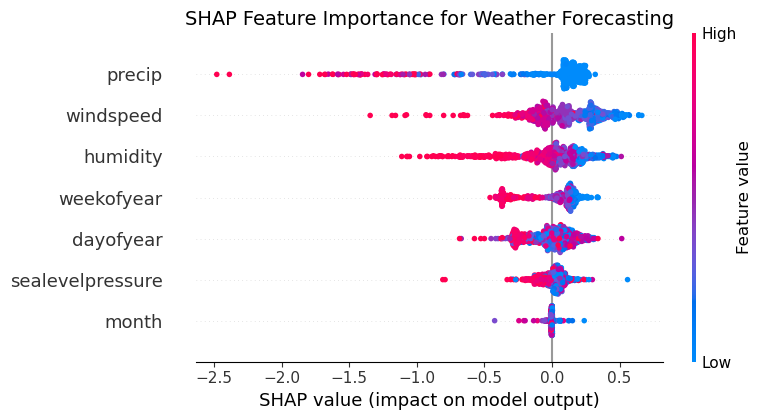

In [100]:
# TreeExplainer use karein kyunki XGBoost ek tree-based model hai
explainer = shap.TreeExplainer(xgb_residual) # ya fir standalone xgb_pred wala model
shap_values = explainer(X_test)

# Summary Plot generate karne ke liye
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance for Weather Forecasting", fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300) # Paper me daalne ke liye image save karein
plt.show()

In [84]:
!pip install --upgrade scipy shap scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/3b/67/be3d369f40d8178ba3bd86635d132e08cb5329b023e4669d9426d84bc007/scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.4.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Obtaining dependency information for narwhals>=2.0.1 from https://files.pythonhosted.org/packages/1f/b6/e7cdde7b8e90d5dff25b622f95833ef26567ad184c977278b93a1cbd5717/narwhals-2.22.0-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.5.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
    --------------------------------------- 0.2/8.3 MB 3.9 MB/s eta 0:00:03
   -- 

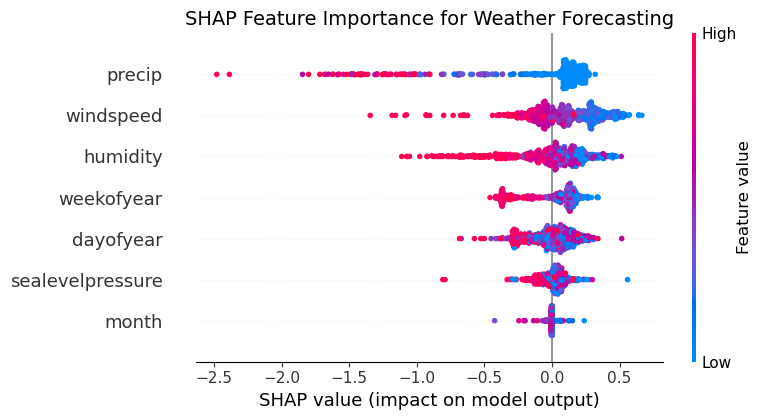

In [98]:
import shap
import matplotlib.pyplot as plt

# TreeExplainer use karein kyunki XGBoost ek tree-based model hai
# Yahan check kar lena ki aapka residual model 'xgb_residual' naam se hi save hai na
explainer = shap.TreeExplainer(xgb_residual) 
shap_values = explainer(X_test)

# Summary Plot generate karne ke liye
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance for Weather Forecasting", fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300) # Paper me daalne ke liye image save ho jayegi
plt.show()

In [90]:
!pip uninstall -y shap scikit-learn


Found existing installation: shap 0.51.0
Uninstalling shap-0.51.0:
  Successfully uninstalled shap-0.51.0


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\HP\Desktop\New folder\Lib\site-packages\pip\_internal\cli\base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "C:\Users\HP\Desktop\New folder\Lib\site-packages\pip\_internal\commands\uninstall.py", line 110, in run
    uninstall_pathset.commit()
  File "C:\Users\HP\Desktop\New folder\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 432, in commit
    self._moved_paths.commit()
  File "C:\Users\HP\Desktop\New folder\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 278, in commit
    save_dir.cleanup()
  File "C:\Users\HP\Desktop\New folder\Lib\site-packages\pip\_internal\utils\temp_dir.py", line 173, in cleanup
    rmtree(self._path)
  File "C:\Users\HP\Desktop\New folder\Lib\site-packages\pip\_vendor\tenacity\__init__.py", line 291, in wrapped_f
    return self(f, *args, **kw)
           ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\HP\Desk

In [91]:
!pip install scikit-learn==1.3.2 shap==0.44.1

  Obtaining dependency information for scikit-learn==1.3.2 from https://files.pythonhosted.org/packages/4e/ba/ce9bd1cd4953336a0e213b29cb80bb11816f2a93de8c99f88ef0b446ad0c/scikit_learn-1.3.2-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for shap==0.44.1 from https://files.pythonhosted.org/packages/a3/89/f5cca6e299320e19194ad09f6014db33208a49e8d9161e729725eb17f8a8/shap-0.44.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for numpy<2.0,>=1.17.3 from https://files.pythonhosted.org/packages/3f/6b/5610004206cf7f8e7ad91c5a85a8c71b2f2f8051a0c0c4d5916b76d6cbb2/numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
  Obtaining dependency information for slicer==0.0.7 from https://files.pythonhosted.org/packages/78/c2/b3f55dfdb8af9812fdb9baf70cacf3b9e82e505b2bd4324d588888b81202/slicer-0.0.7-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
  

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [97]:
!pip install --upgrade --force-reinstall --no-dependencies scikit-learn==1.3.2 shap==0.44.1 scipy==1.11.4

  Obtaining dependency information for scikit-learn==1.3.2 from https://files.pythonhosted.org/packages/4e/ba/ce9bd1cd4953336a0e213b29cb80bb11816f2a93de8c99f88ef0b446ad0c/scikit_learn-1.3.2-cp311-cp311-win_amd64.whl.metadata
  Using cached scikit_learn-1.3.2-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for shap==0.44.1 from https://files.pythonhosted.org/packages/a3/89/f5cca6e299320e19194ad09f6014db33208a49e8d9161e729725eb17f8a8/shap-0.44.1-cp311-cp311-win_amd64.whl.metadata
  Using cached shap-0.44.1-cp311-cp311-win_amd64.whl.metadata (25 kB)
  Obtaining dependency information for scipy==1.11.4 from https://files.pythonhosted.org/packages/43/d0/f3cd75b62e1b90f48dbf091261b2fc7ceec14a700e308c50f6a69c83d337/scipy-1.11.4-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/60.4 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.4 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.4 kB 

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\HP\\Desktop\\New folder\\Lib\\site-packages\\~cipy\\io\\matlab\\_mio5_utils.cp311-win_amd64.pyd'
Consider using the `--user` option or check the permissions.

